# Finsler Flow Matching on the Sheet

Reproduces the paper's Sheet path figure and the table. Runtime ≈ 20 GPU-min.

**The task.** A saddle surface carries two populations, $p_0$ and $p_1$, separated by a
strip of cells that is withheld. That narrow strip is representing a high probability tranisition data submanifold of the data manifold. The dataset contains datapoints and a transition probability matrix between them.

In [1]:
%matplotlib inline
import matplotlib
_NB_BACKEND = matplotlib.get_backend()
import pathlib
import sys
_here = pathlib.Path.cwd().resolve()
PUBLIC = next((p for p in (_here, *_here.parents)
               if (p / "scripts").is_dir() and (p / "notebooks").is_dir()), None)
assert PUBLIC is not None, "run this from inside the repo's public/ tree"
sys.path.insert(0, str(PUBLIC))

import dataclasses
import json
import time

import numpy as np
import ot
import pandas as pd
import scipy.sparse as sp
import torch

from scripts.experiments.sheet.datasets import (DECOY, GAP, P_KNN_K, SHEET_CORRIDOR,
                                        SOURCE, TARGET, make_dataset)
from scripts.experiments.sheet.evaluate import (MOMENT_GROUPS, evaluate_route,
                                                holdout_moment_fidelity)
from scripts.experiments.sheet.paper_focus import (PATHB_NAME, QUAL_DET,
                                           QUAL_NOISY, two_line)
from scripts.experiments.sheet.protocol import corridor_mask, pooled_slices
from scripts.experiments.sheet.split import (make_split, split_route_eval,
                                     split_training_set)
from scripts.experiments.sheet import tune as sheet_tune
from scripts.core.arms import HParams, run_arm
from scripts.core.metrics import mean_floor
from scripts.core.paths import figure_dir, rel   # notebooks/out, or out_smoke
import scripts.method
from scripts.method import (FWFactory, Run, c_eff_of, cuda_warm_up,
                   euclidean_w2, finsler_w2, moments_from, path_a, path_b,
                   pct_change, results_table, rho_star, seed_frame, sigma_for)
from scripts.method import figures as nbfig

import matplotlib.pyplot as plt

matplotlib.use(_NB_BACKEND)

pf = nbfig.sheet_primitives()
pd.set_option("display.width", 200)

## Hyperparamters
The hyperparameters were tuned in a separate run using scripts/experiments/sheet/tune.py and loaded here from the saved values in scripts/experiments/sheet/tuned.json.

In [2]:
cfg = Run.from_env()     

FW_RHO_MULT = 1.0
FW_LAM_MULT = 0.3
FW_RHO_MULT_RUNGS = sheet_tune.RHO_MULTS          
FW_LAM_MULT_RUNGS = sheet_tune.LAM_MULTS         
SB_WIDTH_MULT_RUNGS = sheet_tune.SIGMA_MULTS   
print(f"FW_RHO_MULT_RUNGS {FW_RHO_MULT_RUNGS}")   
print(f"FW_LAM_MULT_RUNGS {FW_LAM_MULT_RUNGS}")   
print(f"SB_WIDTH_MULT_RUNGS {SB_WIDTH_MULT_RUNGS}")   

FFM_DET = f"{PATHB_NAME} (ours), {QUAL_DET}"
FFM_SDE = f"{PATHB_NAME} (ours), {QUAL_NOISY}"

FW_RHO_MULT_RUNGS (0.3, 1.0, 3.0)
FW_LAM_MULT_RUNGS (0.1, 0.3, 1.0, 3.0, 10.0)
SB_WIDTH_MULT_RUNGS (0.03, 0.1, 0.3, 1.0, 3.0)


## Dataset


p0 966  p1 1033
withheld: 112 cells


wrote notebooks/out/sheet_dataset.png


wrote notebooks/out/sheet_dataset.pdf


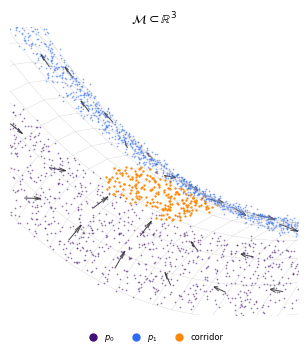

In [3]:
ds    = make_dataset("Sheet")                      # N = 4000, d = 3
split = make_split(ds, seed=cfg.split_seed)        # drawn once and held fixed
ts    = split_training_set(ds, split)
rev   = split_route_eval(ds, split, "test")        # the withheld corridor + p_1

X, P = np.asarray(ts.X, dtype=np.float64), sp.csr_matrix(ts.P)
N, d = X.shape
p0_mask, p1_mask = ts.p0, ts.p1
X_t  = cfg.tensor(X)
X0_t = X_t[torch.as_tensor(p0_mask, device=cfg.device)]
X1_t = X_t[torch.as_tensor(p1_mask, device=cfg.device)]

_fro = lambda A: float(np.sqrt(sp.csr_matrix(A).power(2).sum()))
print(f"p0 {int(p0_mask.sum())}  p1 {int(p1_mask.sum())}")
print(f"withheld: {len(rev.corridor_ref)} cells")

b0_pts, D_pts = moments_from(P, X)
fw = FWFactory(X, D_pts, b0_pts, cfg, rho_mult=FW_RHO_MULT, lam_mult=FW_LAM_MULT)
FW_RHO_RUNGS = fw.rho_rungs(FW_RHO_MULT_RUNGS)
FW_LAM_RUNGS = fw.lam_rungs(FW_LAM_MULT_RUNGS)


_u, _w = ds.uv[ts.idx, 0], ds.uv[ts.idx, 1]
_corr  = corridor_mask(ds)                       
_LO, _HI = pf._limits(ds)

fig = plt.figure(figsize=(5.0, 3.4), layout="constrained")
ax3 = fig.add_subplot(111, projection="3d")
_U, _W = np.meshgrid(np.linspace(-pf.SHEET_L, pf.SHEET_L, 25),
                     np.linspace(-pf.SHEET_W, pf.SHEET_W, 9))
ax3.plot_wireframe(_U, _W, pf._sheet_z(_U, _W), color=nbfig.FAINT, linewidth=0.35,
                   alpha=0.5, zorder=0)

pf._scatter_cloud(ax3, ds, _corr, three_d=True, s=1.5, alpha_scale=1.35)


_A_LEN, _A_RAD = 0.09, 0.16
_Pasym = (P - P.T) * 0.5
_J_pts = np.asarray(_Pasym @ X) - np.asarray(_Pasym.sum(axis=1)) * X


_a_pts = np.array([[_uu, _ww] for _ww in (-0.36, -0.21, 0.21, 0.36)
                   for _uu in np.linspace(-1.15, 1.15, 8)])
_a_vec = np.asarray([_J_pts[np.linalg.norm(np.c_[_u, _w] - _p, axis=1) < _A_RAD].mean(0)
                     for _p in _a_pts])
_h  = 1e-3
_zu = (pf._sheet_z(_a_pts[:, 0] + _h, _a_pts[:, 1])
       - pf._sheet_z(_a_pts[:, 0] - _h, _a_pts[:, 1])) / (2 * _h)
_zw = (pf._sheet_z(_a_pts[:, 0], _a_pts[:, 1] + _h)
       - pf._sheet_z(_a_pts[:, 0], _a_pts[:, 1] - _h)) / (2 * _h)
_a_vec = np.c_[_a_vec[:, 0], _a_vec[:, 1], _zu * _a_vec[:, 0] + _zw * _a_vec[:, 1]]
_a_vec *= _A_LEN / (np.linalg.norm(_a_vec, axis=1, keepdims=True) + 1e-12)


_a_xyz = np.c_[_a_pts, pf._sheet_z(_a_pts[:, 0], _a_pts[:, 1])] - _a_vec / 2
ax3.quiver(*_a_xyz.T, *_a_vec.T, color="#3a3a3a", linewidth=0.75, arrow_length_ratio=0.4,
           alpha=0.9, zorder=3)

pf._style_3d(ax3, _LO, _HI, zoom=2.6)
ax3.view_init(elev=26.0, azim=-40.0)
ax3.set_title(r"$\mathcal{M} \subset \mathbb{R}^3$", fontsize=cfg.fs_heading + 1, pad=-4)


fig.legend(handles=pf._legend_handles(ds, _corr, extra_paths=False),
           loc="outside lower center", ncol=3, frameon=False,
           fontsize=cfg.fs_legend + 1, handletextpad=0.3, columnspacing=1.6)

_stem = pathlib.Path(figure_dir(cfg.smoke)) / "sheet_dataset"
_stem.parent.mkdir(parents=True, exist_ok=True)
for _ext in ("png", "pdf"):
    fig.savefig(_stem.with_suffix(f".{_ext}"), dpi=300, bbox_inches="tight")
    print(f"wrote {rel(_stem.with_suffix('.' + _ext))}")
plt.show()

## Phases 1–3

**1. Geodesic interpolant.** $x_{t}=(1-t)x_0+tx_1+t(1-t)\varphi_\eta(t,x_0,x_1)$, fitted
by minimising $\mathbb{E}\,F(x_t,\dot x_t)^2$. Boundary conditions hold by construction.

**2. Geometry-aware OT.** $C_{ij}=\frac1K\sum_k F(x_{t_k},\dot x_{t_k})^2$ along the
frozen interpolant, then entropic Sinkhorn for $\pi^*$.

**3. Distillation.** $\mathbb{E}\,\|v_\theta(t,x_t)-\dot x_t\|^2$ under $\pi^*$, then
RK4 from $p_0$.


## Run

In [4]:

TUNED = {
    'ffm': {'rho_mult': 1.000000e+00, 'lam_mult': 3.000000e-01},
    'mfm_land': {'land_rho': 1.000000e-03},
    'curly': {'curly_alpha': 1.000000e+00},
    'cfm': {},
    'pathb': {'width_mult': 3.000000e-01},
}

_saved = json.loads((PUBLIC / "scripts/experiments/sheet/tuned.json").read_text())
assert TUNED == _saved, "TUNED is stale -- re-run `tune.py collect` and re-paste it"
assert set(TUNED) == {"ffm", "mfm_land", "curly", "cfm", "pathb"}, sorted(TUNED)


if cuda_warm_up(fw.at(rho=FW_RHO_RUNGS[0], lam=FW_LAM_RUNGS[0]), X0_t, X1_t, cfg):
    print("cuda warm-up done, discarded -- scripts.method.phases.cuda_warm_up says why\n")

metric_star = fw.at(rho=fw.rho_rungs([TUNED["ffm"]["rho_mult"]])[0],
                    lam=fw.lam_rungs([TUNED["ffm"]["lam_mult"]])[0])

runs = {}
for seed in cfg.seeds:
    t0 = time.time()
    print(f"--- {FFM_DET}  seed {seed} ---")
    out = path_a(metric_star, X0_t, X1_t, seed, cfg, verbose=(seed == cfg.seeds[0]))
    out["sigma"] = 0.0
    out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                    device=cfg.device, dtype=cfg.dtype, seed=0)
    runs[(FFM_DET, seed)] = out
    m = out["metrics"]
    print(f"    mid W2 {m['intermediate']['W2']:.4f}   "
          f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.1f}s)")

cuda warm-up done, discarded -- scripts.method.phases.cuda_warm_up says why

--- FFM (ours), deterministic  seed 0 ---
    iter     0  L_geo 0.52385


    iter   250  L_geo 0.24497


    iter   500  L_geo 0.21603


    iter   750  L_geo 0.15203


    iter  1000  L_geo 0.14153


...

    iter  1250  L_CFM 0.03333


    iter  1499  L_CFM 0.03231


    mid W2 0.1636   end W2 0.1930   (31.5s)
--- FFM (ours), deterministic  seed 1 ---


    mid W2 0.1673   end W2 0.2565   (31.3s)
--- FFM (ours), deterministic  seed 2 ---


    mid W2 0.1454   end W2 0.2532   (31.4s)


##  baselines

In [5]:
BASE_N_STEPS = 102         
BASELINES = {"OT-CFM": "cfm", "MFM / LAND": "mfm_land", "Curly-FM": "curly"}


ts_base = dataclasses.replace(ts, velocity=b0_pts)
assert np.allclose(ts_base.velocity, moments_from(P, X)[0]), \
    "Curly-FM's channel must be the first moment sum_j P_ij (x_j - x_i)"
assert not np.allclose(ts_base.velocity, ds._v_gen[ts.idx]), \
    "Curly-FM must never see the generator velocity field -- only P is public"


base_hp = cfg.arm_kw
assert base_hp["width"] == cfg.net_width and base_hp["depth"] == cfg.net_depth
assert base_hp["curly_net"] == "shared"

base_tuned = {label: TUNED[arm] for label, arm in BASELINES.items()}


def run_baseline(label, seed, **over):
    """One engine arm at one point, in this notebook's ``runs`` shape."""
    hp = HParams(**{**base_hp, **over})
    res = run_arm(BASELINES[label], ts_base, hp, seed, cfg.device, cfg.dtype,
                  n_steps=BASE_N_STEPS)
    return {"phi": None, "v_net": res.v_net, "sigma": 0.0,
            "traj": np.asarray(res.traj, dtype=np.float64), "ot": res.diag}


for label, point in base_tuned.items():
    print(f"{label:12s} {point or 'nothing to select'}")
    for seed in cfg.seeds:
        t0 = time.time()
        out = run_baseline(label, seed, **point)
        out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                        device=cfg.device, dtype=cfg.dtype, seed=0)
        runs[(label, seed)] = out
        m = out["metrics"]
        print(f"{label:12s} seed {seed}   mid W2 {m['intermediate']['W2']:.4f}   "
              f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.0f}s)")

OT-CFM       nothing to select


    [cfm]    iter     0  L_CFM = 0.233391


    [cfm]    iter   250  L_CFM = 0.027058


    [cfm]    iter   500  L_CFM = 0.024455


    [cfm]    iter   750  L_CFM = 0.019362


...

    [phase2] iter  1499  L_CFM = 0.138390


MFM / LAND   seed 2   mid W2 0.6899   end W2 0.2300   (28s)
Curly-FM     {'curly_alpha': 1.0}


Curly-FM     seed 0   mid W2 0.5229   end W2 0.1396   (48s)


Curly-FM     seed 1   mid W2 0.5199   end W2 0.1479   (48s)


Curly-FM     seed 2   mid W2 0.5235   end W2 0.1341   (49s)


## FFM with noise

In [6]:

SB_WIDTH_MULT = TUNED["pathb"]["width_mult"]
SIGMA_B = sigma_for(metric_star, SB_WIDTH_MULT)


for seed in cfg.seeds:
    t0 = time.time()
    ref = runs[(FFM_DET, seed)]
    out = path_b(metric_star, ref["phi"], ref["coupler"], X0_t, SIGMA_B, seed, cfg,
                 verbose=(seed == cfg.seeds[0]))
    out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                    device=cfg.device, dtype=cfg.dtype, seed=0)
    runs[(FFM_SDE, seed)] = out
    m = out["metrics"]
    print(f"{FFM_SDE:28s} seed {seed}   mid W2 {m['intermediate']['W2']:.4f}   "
          f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.0f}s)")

REPORTED = [FFM_DET, FFM_SDE, *BASELINES]

    iter     0  L_CFM 0.93595  L_CSM 412.74384


    iter   250  L_CFM 0.05504  L_CSM 449.97836


    iter   500  L_CFM 0.04617  L_CSM 460.36499


    iter   750  L_CFM 0.03526  L_CSM 475.26556


    iter  1000  L_CFM 0.04433  L_CSM 472.71298


    iter  1250  L_CFM 0.03412  L_CSM 472.43188


    iter  1499  L_CFM 0.04470  L_CSM 476.92181


FFM (ours), with noise       seed 0   mid W2 0.1432   end W2 0.1976   (17s)


FFM (ours), with noise       seed 1   mid W2 0.1599   end W2 0.2355   (17s)


FFM (ours), with noise       seed 2   mid W2 0.1316   end W2 0.3575   (17s)


## Table

In [7]:

COLUMNS = {**scripts.method.BASE_COLUMNS, "cos(v, b0)": ("drift", "cos")}
print(results_table(runs, REPORTED, cfg.seeds, COLUMNS,
                    floors=runs[(FFM_DET, cfg.seeds[0])]["metrics"]["floors"]).to_string())

_mean = lambda nm, c: seed_frame(runs, nm, cfg.seeds, COLUMNS)[c].mean()
best_base = min(BASELINES, key=lambda b: _mean(b, "mid W2"))

                                    mid W2           end W2       cos(v, b0)
FFM (ours), deterministic  0.1588 ± 0.0096  0.2343 ± 0.0292  0.8977 ± 0.0363
FFM (ours), with noise     0.1449 ± 0.0116  0.2636 ± 0.0682  0.8835 ± 0.0293
OT-CFM                     0.7112 ± 0.0233  0.1734 ± 0.0216  0.4679 ± 0.0212
MFM / LAND                 0.6843 ± 0.0074  0.2357 ± 0.0258  0.5205 ± 0.0584
Curly-FM                   0.5221 ± 0.0016  0.1405 ± 0.0057  0.8970 ± 0.0023
sampling floor                      0.0646           0.1896               --


## Finsler Wasserstein 


In [8]:

JUDGE = (runs[(FFM_DET, cfg.seeds[0])]["phi"], metric_star)

_corr_ref = np.asarray(rev.corridor_ref, dtype=np.float64)
_fl = mean_floor(_corr_ref, len(pooled_slices(runs[(FFM_DET, cfg.seeds[0])]["traj"],
                                              rev.t_lo, rev.t_hi)),
                 lambda a, b, k: {"WF": finsler_w2(a, b, JUDGE, cfg, seed=k),
                                  "WE": euclidean_w2(a, b, seed=k)})

wf_rows, eu_rows = {}, {}
for nm in REPORTED:
    _clouds = [pooled_slices(runs[(nm, s)]["traj"], rev.t_lo, rev.t_hi) for s in cfg.seeds]
    _v = [finsler_w2(c, _corr_ref, JUDGE, cfg, seed=s) for c, s in zip(_clouds, cfg.seeds)]
    wf_rows[nm] = (float(np.mean(_v)), float(np.std(_v)))
    eu_rows[nm] = float(np.mean([euclidean_w2(c, _corr_ref, seed=s)
                                 for c, s in zip(_clouds, cfg.seeds)]))

print(f"Finsler Wasserstein  W_2,F  between the pooled t in [{rev.t_lo:.2f}, "
      f"{rev.t_hi:.2f}] cloud and the {len(_corr_ref)} withheld corridor cells,")
print(f"under c_F from the tuned FFM metric.  Path B rows were integrated under the SDE.\n")
_w2 = max(len(n) for n in REPORTED) + 2
print(f"{'':<{_w2}s}{'W_2,F':>18s}{'Euclidean W_2':>18s}")
for nm in REPORTED:
    print(f"{nm:<{_w2}s}{wf_rows[nm][0]:>11.4f} ± {wf_rows[nm][1]:.4f}{eu_rows[nm]:>18.4f}")
print(f"{'sampling floor':<{_w2}s}{_fl['WF']:>18.4f}"
      f"{_fl['WE']:>18.4f}")


Finsler Wasserstein  W_2,F  between the pooled t in [0.36, 0.64] cloud and the 112 withheld corridor cells,
under c_F from the tuned FFM metric.  Path B rows were integrated under the SDE.

                                        W_2,F     Euclidean W_2
FFM (ours), deterministic       0.2892 ± 0.0090            0.1643
FFM (ours), with noise          0.2742 ± 0.0314            0.1497
OT-CFM                          1.0305 ± 0.0263            0.7148
MFM / LAND                      0.8645 ± 0.0961            0.6874
Curly-FM                        0.5236 ± 0.1657            0.5271
sampling floor                         0.2812            0.0646


## Figure

wrote notebooks/out/sheet_paths.png
wrote notebooks/out/sheet_paths.pdf


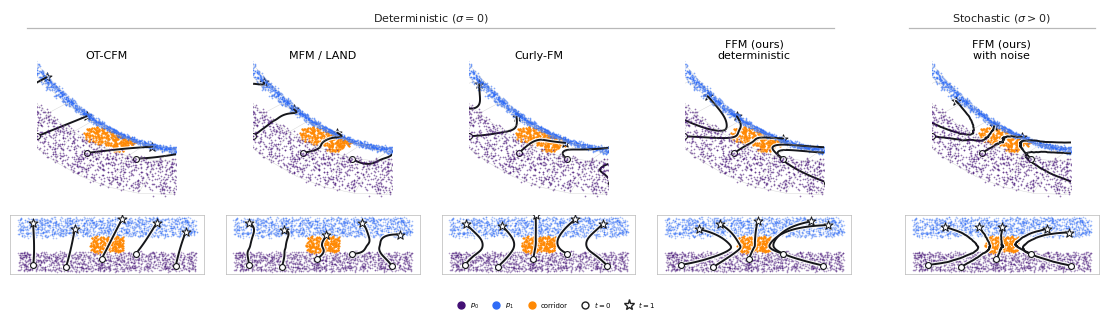

In [9]:

_corr = corridor_mask(ds)
_LO, _HI = pf._limits(ds)
_PLANE_RATIO = float((_HI[1] - _LO[1]) / (_HI[0] - _LO[0])) + 0.14

FIG_BLOCKS = [
    (r"Deterministic ($\sigma = 0$)", ["OT-CFM", "MFM / LAND", "Curly-FM", FFM_DET]),
    (r"Stochastic ($\sigma > 0$)",    [FFM_SDE]),
]
FIG_LABELS = {**{nm: nm for nm in BASELINES},
              FFM_DET: two_line(QUAL_DET, ours=True),
              FFM_SDE: two_line(QUAL_NOISY, ours=True)}


_n_src = min(runs[(nm, cfg.seeds[0])]["traj"].shape[1] for nm in REPORTED)
_cols = pf._lateral_starts(runs[(FFM_DET, cfg.seeds[0])]["traj"][0, :_n_src], 5)

bg = nbfig.BlockGrid(
    [(heading, [(FIG_LABELS[nm], runs[(nm, cfg.seeds[0])]["traj"][:, _cols])
                for nm in arms]) for heading, arms in FIG_BLOCKS],
    row_ratios=(0.84, _PLANE_RATIO), height=3.05, heading_fs=cfg.fs_heading)

for bi, (_heading, cols) in enumerate(bg.blocks):
    for k, (label, tr) in enumerate(cols):
        ax3 = bg.ax(1, bi, k, projection="3d")
        pf._surface(ax3, alpha=0.5, lw=0.35)
        pf._scatter_cloud(ax3, ds, _corr, three_d=True, s=1.5, alpha_scale=1.35)
        pf._draw_paths(ax3, tr, three_d=True)
        pf._style_3d(ax3, _LO, _HI, zoom=pf.PANEL_ZOOM)
        ax3.set_title(label, fontsize=cfg.fs_heading, linespacing=1.1,
                      pad=-6 - cfg.fs_heading * label.count("\n"))

        ax2 = bg.ax(2, bi, k)
        pf._scatter_cloud(ax2, ds, _corr, three_d=False, s=1.4)
        pf._draw_paths(ax2, tr, three_d=False)
        pf._style_2d(ax2, _LO, _HI)

bg.legend(list(pf._legend_handles(ds, _corr, extra_paths=True)), fontsize=cfg.fs_legend)
for _p in bg.save(pathlib.Path(figure_dir(cfg.smoke)) / "sheet_paths"):
    print(f"wrote {rel(_p)}")
plt.show()

## Ablation of Finsler, Euclidean and Riemannian in Geodesic network

G = I, no drift         a_bar 0.04922   lam 49.22   c_eff 0.0010   max beta^T G^-1 beta 0.000003
G = I, drift            a_bar 0.04922   lam 0.01477   c_eff 0.9578   max beta^T G^-1 beta 0.973088
G = C_rho, no drift     a_bar 0.7626   lam 762.6   c_eff 0.0010   max beta^T G^-1 beta 0.000001
G = C_rho, drift        a_bar 0.7626   lam 0.2288   c_eff 0.9578   max beta^T G^-1 beta 0.939883



G = I, no drift        seed 0   mid W2 0.7251   end W2 0.1399   (30s)


G = I, no drift        seed 1   mid W2 0.6974   end W2 0.1796   (31s)


G = I, no drift        seed 2   mid W2 0.7270   end W2 0.2058   (31s)


G = I, drift           seed 0   mid W2 0.2075   end W2 0.2240   (31s)


...

G = C_rho, no drift    seed 0   mid W2 0.6456   end W2 0.2107   (32s)


G = C_rho, no drift    seed 1   mid W2 0.6724   end W2 0.1918   (32s)


G = C_rho, no drift    seed 2   mid W2 0.6837   end W2 0.2049   (32s)



Metric ablation on the Sheet: rho = 0.001268 held fixed, 3 seeds, W_2,F under the same fixed judge as the table above.
                     c_eff           mid W2           end W2            W_2,F
G = I, no drift      0.001  0.7165 ± 0.0136  0.1751 ± 0.0271  1.0840 ± 0.0371
G = I, drift         0.958  0.2541 ± 0.0375  0.2558 ± 0.0509  0.3676 ± 0.0773
G = C_rho, no drift  0.001  0.6672 ± 0.0160  0.2025 ± 0.0079  0.9437 ± 0.1068
G = C_rho, drift     0.958  0.1588 ± 0.0096  0.2343 ± 0.0292  0.2892 ± 0.0090
sampling floor                       0.0646           0.1896           0.2812


wrote notebooks/out/sheet_metric_ablation.png
wrote notebooks/out/sheet_metric_ablation.pdf


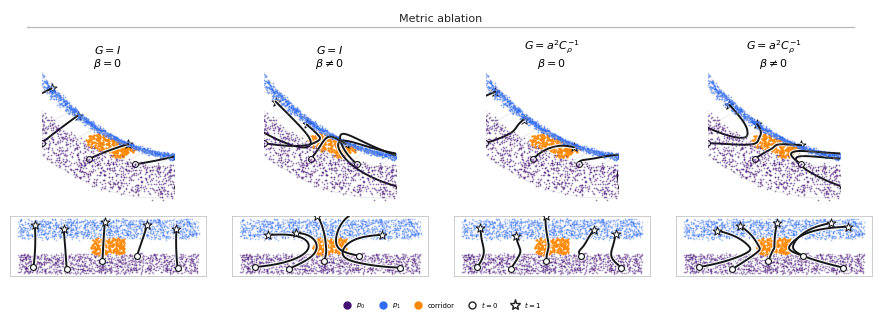

In [10]:
from scripts.method import TrueFW


class EuclideanFW(TrueFW):
    def mobility(self, x):
        return self.I[None].expand(x.shape[0], self.d, self.d)

    def _fields(self, x):
        b = self._smooth(self._kernel(x), self.b0_pts) + self.eps_b
        return self.I[None].expand(x.shape[0], self.d, self.d), b


ABL_RHO = fw.rho_rungs([TUNED["ffm"]["rho_mult"]])[0]
ABL_LAM_ON = float(TUNED["ffm"]["lam_mult"])
ABL_LAM_OFF = 1000.0

ABL_EUCL_OFF = "G = I, no drift"
ABL_EUCL_ON = "G = I, drift"
ABL_RIEM = "G = C_rho, no drift"
ABL_FULL = "G = C_rho, drift"
ABL_ORDER = [ABL_EUCL_OFF, ABL_EUCL_ON, ABL_RIEM, ABL_FULL]


def abl_metric(cls, lam_mult):
    return cls(X, D_pts, b0_pts, cfg, rho=ABL_RHO, lam=None,
               lam_mult=lam_mult).calibrate()


ABL_METRIC = {
    ABL_EUCL_OFF: abl_metric(EuclideanFW, ABL_LAM_OFF),
    ABL_EUCL_ON: abl_metric(EuclideanFW, ABL_LAM_ON),
    ABL_RIEM: abl_metric(TrueFW, ABL_LAM_OFF),
    ABL_FULL: metric_star,
}
assert abs(ABL_METRIC[ABL_FULL].lam - fw.lam_rungs([ABL_LAM_ON])[0]) < 1e-12, \
    "the full rung of the ablation must be the tuned metric itself"
assert abs(c_eff_of(ABL_METRIC[ABL_EUCL_ON]) - c_eff_of(ABL_METRIC[ABL_FULL])) < 1e-9, \
    "the two drift-on rungs must carry the same 1-form strength"

for _nm in ABL_ORDER:
    _mt = ABL_METRIC[_nm]
    _G, _be = _mt.tensors(_mt.X[:1024])
    _q = torch.einsum("bi,bij,bj->b", _be, torch.linalg.inv(_G), _be)
    assert float(_q.max()) < 1.0, f"{_nm} is not an admissible Randers metric"
    print(f"{_nm:22s}  a_bar {_mt.a_bar:.4g}   lam {_mt.lam:.4g}   "
          f"c_eff {c_eff_of(_mt):.4f}   max beta^T G^-1 beta {float(_q.max()):.6f}")
print()

abl = {}
for _nm in ABL_ORDER:
    for seed in cfg.seeds:
        if _nm == ABL_FULL:
            abl[(_nm, seed)] = runs[(FFM_DET, seed)]
            continue
        t0 = time.time()
        out = path_a(ABL_METRIC[_nm], X0_t, X1_t, seed, cfg, verbose=False)
        out["sigma"] = 0.0
        out["metrics"] = evaluate_route(out["traj"], ds, rev, v_net=out["v_net"],
                                        device=cfg.device, dtype=cfg.dtype, seed=0)
        abl[(_nm, seed)] = out
        m = out["metrics"]
        print(f"{_nm:22s} seed {seed}   mid W2 {m['intermediate']['W2']:.4f}   "
              f"end W2 {m['endpoint']['W2']:.4f}   ({time.time() - t0:.0f}s)")
print()

ABL_REF = np.asarray(rev.corridor_ref, dtype=np.float64)
_abl_fl = mean_floor(ABL_REF, len(pooled_slices(abl[(ABL_FULL, cfg.seeds[0])]["traj"],
                                                rev.t_lo, rev.t_hi)),
                     lambda a, b, k: {"WF": finsler_w2(a, b, JUDGE, cfg, seed=k)})

abl_rows = []
for _nm in ABL_ORDER:
    _mid = [abl[(_nm, s)]["metrics"]["intermediate"]["W2"] for s in cfg.seeds]
    _end = [abl[(_nm, s)]["metrics"]["endpoint"]["W2"] for s in cfg.seeds]
    _wf = [finsler_w2(pooled_slices(abl[(_nm, s)]["traj"], rev.t_lo, rev.t_hi),
                      ABL_REF, JUDGE, cfg, seed=s) for s in cfg.seeds]
    abl_rows.append({"c_eff": f"{c_eff_of(ABL_METRIC[_nm]):.3f}",
                     "mid W2": f"{np.mean(_mid):.4f} ± {np.std(_mid):.4f}",
                     "end W2": f"{np.mean(_end):.4f} ± {np.std(_end):.4f}",
                     "W_2,F": f"{np.mean(_wf):.4f} ± {np.std(_wf):.4f}"})

_afl = abl[(ABL_FULL, cfg.seeds[0])]["metrics"]["floors"]
abl_rows.append({"c_eff": "",
                 "mid W2": f"{_afl['intermediate']['W2']:.4f}",
                 "end W2": f"{_afl['endpoint']['W2']:.4f}",
                 "W_2,F": f"{_abl_fl['WF']:.4f}"})

abl_table = pd.DataFrame(abl_rows, index=[*ABL_ORDER, "sampling floor"])
print(f"Metric ablation on the Sheet: rho = {ABL_RHO:.4g} held fixed, {len(cfg.seeds)} "
      f"seeds, W_2,F under the same fixed judge as the table above.")
print(abl_table.to_string())

_acorr = corridor_mask(ds)
_ALO, _AHI = pf._limits(ds)
_APLANE = float((_AHI[1] - _ALO[1]) / (_AHI[0] - _ALO[0])) + 0.14

ABL_LABELS = {
    ABL_EUCL_OFF: "$G = I$\n$\\beta = 0$",
    ABL_EUCL_ON: "$G = I$\n$\\beta \\neq 0$",
    ABL_RIEM: "$G = a^2 C_\\rho^{-1}$\n$\\beta = 0$",
    ABL_FULL: "$G = a^2 C_\\rho^{-1}$\n$\\beta \\neq 0$",
}

_an = min(abl[(nm, cfg.seeds[0])]["traj"].shape[1] for nm in ABL_ORDER)
_acols = pf._lateral_starts(abl[(ABL_FULL, cfg.seeds[0])]["traj"][0, :_an], 5)

abg = nbfig.BlockGrid(
    [("Metric ablation", [(ABL_LABELS[nm], abl[(nm, cfg.seeds[0])]["traj"][:, _acols])
                          for nm in ABL_ORDER])],
    row_ratios=(0.84, _APLANE), height=3.05, heading_fs=cfg.fs_heading)

for k, (label, tr) in enumerate(abg.blocks[0][1]):
    ax3 = abg.ax(1, 0, k, projection="3d")
    pf._surface(ax3, alpha=0.5, lw=0.35)
    pf._scatter_cloud(ax3, ds, _acorr, three_d=True, s=1.5, alpha_scale=1.35)
    pf._draw_paths(ax3, tr, three_d=True)
    pf._style_3d(ax3, _ALO, _AHI, zoom=pf.PANEL_ZOOM)
    ax3.set_title(label, fontsize=cfg.fs_heading, linespacing=1.1,
                  pad=-6 - cfg.fs_heading * label.count("\n"))

    ax2 = abg.ax(2, 0, k)
    pf._scatter_cloud(ax2, ds, _acorr, three_d=False, s=1.4)
    pf._draw_paths(ax2, tr, three_d=False)
    pf._style_2d(ax2, _ALO, _AHI)

abg.legend(list(pf._legend_handles(ds, _acorr, extra_paths=True)), fontsize=cfg.fs_legend)
for _p in abg.save(pathlib.Path(figure_dir(cfg.smoke)) / "sheet_metric_ablation"):
    print(f"wrote {rel(_p)}")
plt.show()

## Ablation Finsler Euclidean Riemannian Metric of CFM

Euclidean     loss rescale 1
Riemannian    loss rescale 0.345562
Finsler       loss rescale 0.29622



Euclidean    seed 0   mid W2 0.1636   end W2 0.1930   (6s)


Euclidean    seed 1   mid W2 0.1673   end W2 0.2565   (6s)


Euclidean    seed 2   mid W2 0.1454   end W2 0.2532   (6s)


Riemannian   seed 0   mid W2 0.1478   end W2 0.1310   (8s)


...

Finsler      seed 0   mid W2 0.1008   end W2 0.4181   (8s)


Finsler      seed 1   mid W2 0.1390   end W2 0.7416   (8s)


Finsler      seed 2   mid W2 0.0960   end W2 0.6550   (8s)

the Euclidean rung is the table's FFM (ours), deterministic row re-trained: max |traj| deviation 0.00e+00



Phase-3 loss metric on the Sheet: phi and pi* frozen from the tuned FFM run, 3 seeds, 1500 distillation iters, only the weight on the residual r = v_theta - xdot changes.
                         mid W2           end W2            W_2,F wall clock s
Euclidean       0.1588 ± 0.0096  0.2343 ± 0.0292  0.2892 ± 0.0090    6.0 ± 0.0
Riemannian      0.1504 ± 0.0093  0.1837 ± 0.0448  0.2905 ± 0.0258    7.5 ± 0.0
Finsler         0.1119 ± 0.0193  0.6049 ± 0.1367  0.2520 ± 0.0174    7.9 ± 0.0
sampling floor           0.0646           0.1896           0.2812             


wrote notebooks/out/sheet_cfm_loss_metric.png
wrote notebooks/out/sheet_cfm_loss_metric.pdf


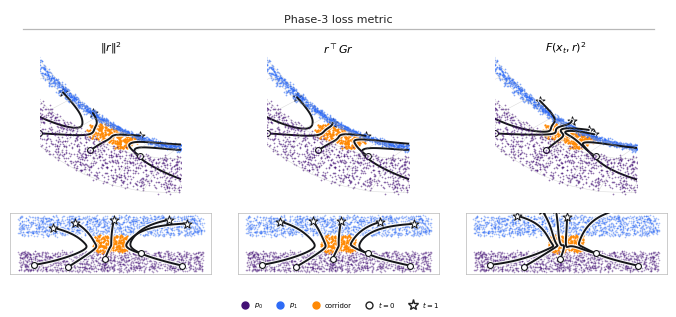

wrote notebooks/out/sheet_cfm_loss_scores.png


wrote notebooks/out/sheet_cfm_loss_scores.pdf


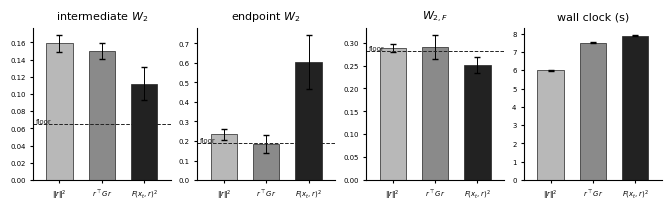

In [11]:
from scripts.method import Coupler, VelocityNet, integrate, interpolant


CFM_EUCL = "Euclidean"
CFM_RIEM = "Riemannian"
CFM_FINS = "Finsler"
CFM_ORDER = [CFM_EUCL, CFM_RIEM, CFM_FINS]
CFM_LABELS = {CFM_EUCL: "$\\|r\\|^2$", CFM_RIEM: "$r^\\top G r$",
              CFM_FINS: "$F(x_t, r)^2$"}


def _cfm_tensors(x):
    with torch.no_grad():
        return metric_star.tensors(x)


def w_eucl(x, r):
    return (r ** 2).mean(1)


def w_riem(x, r):
    G, _ = _cfm_tensors(x)
    return metric_star.scale ** 2 * torch.einsum("bi,bij,bj->b", r, G, r)


def w_fins(x, r):
    G, be = _cfm_tensors(x)
    q = torch.einsum("bi,bij,bj->b", r, G, r).clamp(min=1e-9)
    return (metric_star.scale * (torch.sqrt(q) + (be * r).sum(1))) ** 2


CFM_W = {CFM_EUCL: w_eucl, CFM_RIEM: w_riem, CFM_FINS: w_fins}


def cfm_weight_scale(w, n=4096, seed=0):
    g = torch.Generator(device="cpu").manual_seed(seed)
    i = torch.randperm(N, generator=g)[:n].to(cfg.device)
    r = torch.randn(len(i), d, generator=g).to(cfg.device, cfg.dtype)
    r = r / r.norm(dim=1, keepdim=True)
    with torch.no_grad():
        return float((1.0 / d) / w(X_t[i], r).mean())


CFM_SCALE = {nm: cfm_weight_scale(CFM_W[nm]) for nm in CFM_ORDER}
assert abs(CFM_SCALE[CFM_EUCL] - 1.0) < 1e-6, \
    "the Euclidean rung must need no rescaling, or the loss calibration is not neutral"
for _nm in CFM_ORDER:
    print(f"{_nm:12s}  loss rescale {CFM_SCALE[_nm]:.6g}")
print()


def train_cfm_weighted(phi, coupler, seed, nm):
    w, s = CFM_W[nm], CFM_SCALE[nm]
    torch.manual_seed(seed + 1)
    phi.eval()
    for p in phi.parameters():
        p.requires_grad_(False)
    v_net = VelocityNet(d, **cfg.net_kw).to(cfg.device, cfg.dtype)
    opt = torch.optim.Adam(v_net.parameters(), lr=cfg.cfm_lr)
    for _ in range(cfg.cfm_iters):
        x0, x1 = coupler.sample(cfg.batch)
        t = torch.rand(cfg.batch, 1, **cfg.torch_kw)
        with torch.enable_grad():
            x_t, x_dot = interpolant(phi, t, x0, x1, create_graph=False)
        x_t, x_dot, t = x_t.detach(), x_dot.detach(), t.detach()
        loss = s * w(x_t, v_net(t, x_t) - x_dot).mean()
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(v_net.parameters(), cfg.grad_clip)
        opt.step()
    for p in phi.parameters():
        p.requires_grad_(True)
    return v_net


cfml, cfm_secs = {}, {}
for _nm in CFM_ORDER:
    for seed in cfg.seeds:
        ref = runs[(FFM_DET, seed)]
        cp = Coupler(ref["coupler"].X0, ref["coupler"].X1, pi=ref["coupler"].pi,
                     seed=seed)
        t0 = time.time()
        v_net = train_cfm_weighted(ref["phi"], cp, seed, _nm)
        traj = integrate(v_net, X0_t, cfg).cpu().numpy().astype(np.float64)
        cfm_secs[(_nm, seed)] = time.time() - t0
        out = {"phi": ref["phi"], "coupler": cp, "v_net": v_net, "sigma": 0.0,
               "traj": traj, "ot": ref["ot"]}
        out["metrics"] = evaluate_route(traj, ds, rev, v_net=v_net, device=cfg.device,
                                        dtype=cfg.dtype, seed=0)
        cfml[(_nm, seed)] = out
        m = out["metrics"]
        print(f"{_nm:12s} seed {seed}   mid W2 {m['intermediate']['W2']:.4f}   "
              f"end W2 {m['endpoint']['W2']:.4f}   ({cfm_secs[(_nm, seed)]:.0f}s)")

_cdev = max(float(np.abs(cfml[(CFM_EUCL, s)]["traj"] - runs[(FFM_DET, s)]["traj"]).max())
            for s in cfg.seeds)
print(f"\nthe Euclidean rung is the table's {FFM_DET} row re-trained: "
      f"max |traj| deviation {_cdev:.2e}\n")

CFM_REF = np.asarray(rev.corridor_ref, dtype=np.float64)
_cfm_fl = mean_floor(CFM_REF, len(pooled_slices(cfml[(CFM_EUCL, cfg.seeds[0])]["traj"],
                                                rev.t_lo, rev.t_hi)),
                     lambda a, b, k: {"WF": finsler_w2(a, b, JUDGE, cfg, seed=k)})
CFM_FLOOR = {"mid W2": cfml[(CFM_EUCL, cfg.seeds[0])]["metrics"]["floors"]["intermediate"]["W2"],
             "end W2": cfml[(CFM_EUCL, cfg.seeds[0])]["metrics"]["floors"]["endpoint"]["W2"],
             "W_2,F": _cfm_fl["WF"],
             "wall clock s": None}

cfm_stat = {nm: {
    "mid W2": [cfml[(nm, s)]["metrics"]["intermediate"]["W2"] for s in cfg.seeds],
    "end W2": [cfml[(nm, s)]["metrics"]["endpoint"]["W2"] for s in cfg.seeds],
    "W_2,F": [finsler_w2(pooled_slices(cfml[(nm, s)]["traj"], rev.t_lo, rev.t_hi),
                         CFM_REF, JUDGE, cfg, seed=s) for s in cfg.seeds],
    "wall clock s": [cfm_secs[(nm, s)] for s in cfg.seeds],
} for nm in CFM_ORDER}

CFM_KEYS = ["mid W2", "end W2", "W_2,F", "wall clock s"]
_cprec = lambda k: 1 if k == "wall clock s" else 4
cfm_rows = [{k: f"{np.mean(cfm_stat[nm][k]):.{_cprec(k)}f} ± "
                f"{np.std(cfm_stat[nm][k]):.{_cprec(k)}f}" for k in CFM_KEYS}
            for nm in CFM_ORDER]
cfm_rows.append({k: "" if CFM_FLOOR[k] is None else f"{CFM_FLOOR[k]:.4f}"
                 for k in CFM_KEYS})
cfm_table = pd.DataFrame(cfm_rows, index=[*CFM_ORDER, "sampling floor"])
print(f"Phase-3 loss metric on the Sheet: phi and pi* frozen from the tuned FFM run, "
      f"{len(cfg.seeds)} seeds, {cfg.cfm_iters} distillation iters, only the weight "
      f"on the residual r = v_theta - xdot changes.")
print(cfm_table.to_string())

_ccorr = corridor_mask(ds)
_CLO, _CHI = pf._limits(ds)
_CPLANE = float((_CHI[1] - _CLO[1]) / (_CHI[0] - _CLO[0])) + 0.14

_cn = min(cfml[(nm, cfg.seeds[0])]["traj"].shape[1] for nm in CFM_ORDER)
_ccols = pf._lateral_starts(cfml[(CFM_FINS, cfg.seeds[0])]["traj"][0, :_cn], 5)

cbg = nbfig.BlockGrid(
    [("Phase-3 loss metric",
      [(CFM_LABELS[nm], cfml[(nm, cfg.seeds[0])]["traj"][:, _ccols])
       for nm in CFM_ORDER])],
    row_ratios=(0.84, _CPLANE), height=3.05, heading_fs=cfg.fs_heading)

for k, (label, tr) in enumerate(cbg.blocks[0][1]):
    ax3 = cbg.ax(1, 0, k, projection="3d")
    pf._surface(ax3, alpha=0.5, lw=0.35)
    pf._scatter_cloud(ax3, ds, _ccorr, three_d=True, s=1.5, alpha_scale=1.35)
    pf._draw_paths(ax3, tr, three_d=True)
    pf._style_3d(ax3, _CLO, _CHI, zoom=pf.PANEL_ZOOM)
    ax3.set_title(label, fontsize=cfg.fs_heading, linespacing=1.1,
                  pad=-6 - cfg.fs_heading * label.count("\n"))

    ax2 = cbg.ax(2, 0, k)
    pf._scatter_cloud(ax2, ds, _ccorr, three_d=False, s=1.4)
    pf._draw_paths(ax2, tr, three_d=False)
    pf._style_2d(ax2, _CLO, _CHI)

cbg.legend(list(pf._legend_handles(ds, _ccorr, extra_paths=True)), fontsize=cfg.fs_legend)
for _p in cbg.save(pathlib.Path(figure_dir(cfg.smoke)) / "sheet_cfm_loss_metric"):
    print(f"wrote {rel(_p)}")
plt.show()

CFM_TITLES = {"mid W2": "intermediate $W_2$", "end W2": "endpoint $W_2$",
              "W_2,F": "$W_{2,F}$", "wall clock s": "wall clock (s)"}
CFM_BAR = [nbfig.FAINT, "#8a8a8a", nbfig.INK]

cfig, caxes = plt.subplots(1, len(CFM_KEYS), figsize=(6.6, 2.0), layout="constrained")
_cx = np.arange(len(CFM_ORDER))
for cax, key in zip(caxes, CFM_KEYS):
    _mu = [float(np.mean(cfm_stat[nm][key])) for nm in CFM_ORDER]
    _sd = [float(np.std(cfm_stat[nm][key])) for nm in CFM_ORDER]
    cax.bar(_cx, _mu, yerr=_sd, width=0.62, color=CFM_BAR, edgecolor=nbfig.INK,
            linewidth=0.5, error_kw={"elinewidth": 0.7, "capsize": 2})
    if CFM_FLOOR[key] is not None:
        cax.axhline(CFM_FLOOR[key], color=nbfig.INK, lw=0.7, ls="--")
        cax.text(0.02, CFM_FLOOR[key], "floor", ha="left", va="bottom",
                 fontsize=cfg.fs_legend, color=nbfig.INK,
                 transform=cax.get_yaxis_transform())
    cax.set_xticks(_cx)
    cax.set_xticklabels([CFM_LABELS[nm] for nm in CFM_ORDER],
                        fontsize=cfg.fs_legend + 1)
    cax.set_title(CFM_TITLES[key], fontsize=cfg.fs_heading)
    cax.tick_params(axis="both", labelsize=cfg.fs_legend, length=2)
    cax.margins(x=0.12)
    for _sp in ("top", "right"):
        cax.spines[_sp].set_visible(False)

_cstem = pathlib.Path(figure_dir(cfg.smoke)) / "sheet_cfm_loss_scores"
_cstem.parent.mkdir(parents=True, exist_ok=True)
for _ext in ("png", "pdf"):
    cfig.savefig(_cstem.with_suffix(f".{_ext}"), dpi=300, bbox_inches="tight")
    print(f"wrote {rel(_cstem.with_suffix('.' + _ext))}")
plt.show()
